# Data Science Task 3: Car Price Prediction with Machine Learning

**Author:** Zakia Abdalla  
**Program:** Oasis Infobyte Data Science Internship (OIBSIP)  
**Domain:** Machine Learning & Data Science  

---

## 📌 Project Overview
The used car market valuation depends heavily on numerous factors such as vehicle age, showroom price, total distance driven, fuel type, transmission system, and seller status. Accurate price prediction allows buyers and sellers to make informed financial transactions.

## 🎯 Objectives
1. Load and clean used car price dataset (`car_data.csv`).
2. Remove duplicate records and handle missing values.
3. Feature Engineering: Derive `Car_Age` from manufacturing `Year`.
4. Encode categorical variables using One-Hot Encoding (`pd.get_dummies`).
5. Split data into Training (80%) and Testing (20%) sets.
6. Train multiple regression models (Linear Regression, Lasso, Ridge, Random Forest Regressor, Gradient Boosting Regressor).
7. Evaluate models using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and $R^2$ Score.
8. Generate Feature Importance chart for the top model.


In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Aesthetics setup
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
print("Machine learning & visualization libraries loaded!")


Machine learning & visualization libraries loaded!


## 1. Data Loading & Cleaning

In [2]:
# Read car dataset
df_raw = pd.read_csv('car_data.csv')

print(f"Raw Dataset Shape: {df_raw.shape}")
print("\n--- Dataset First 5 Rows ---")
display(df_raw.head())

print("\n--- Dataset Summary Info ---")
df_raw.info()

print("\n--- Missing Values Count ---")
print(df_raw.isnull().sum())

# Check and remove duplicates
duplicate_count = df_raw.duplicated().sum()
print(f"\nDuplicate rows found: {duplicate_count}")

df = df_raw.drop_duplicates().copy()
print(f"Dataset shape after removing duplicates: {df.shape}")


Raw Dataset Shape: (306, 9)

--- Dataset First 5 Rows ---


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,city,2009,1.70,8.15,246862,Petrol,Individual,Manual,0
1,i20,2006,1.30,9.16,165953,Petrol,Individual,Automatic,0
2,kwid,2015,1.86,6.28,144060,Petrol,Dealer,Manual,0
3,verna,2017,2.17,5.05,95915,Petrol,Dealer,Manual,0
4,xuv500,2013,1.59,6.64,114751,Petrol,Dealer,Manual,0



--- Dataset Summary Info ---
<class 'pandas.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       306 non-null    str    
 1   Year           306 non-null    int64  
 2   Selling_Price  306 non-null    float64
 3   Present_Price  306 non-null    float64
 4   Kms_Driven     306 non-null    int64  
 5   Fuel_Type      306 non-null    str    
 6   Seller_Type    306 non-null    str    
 7   Transmission   306 non-null    str    
 8   Owner          306 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.6 KB

--- Missing Values Count ---
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Duplicate rows found: 5
Dataset shape after removing duplicates: (301, 9)


### 📊 Data Cleaning Observations
- Initial dataset contained 306 rows and 9 columns.
- 5 duplicate entries were identified and removed, leaving 301 unique records.
- Zero missing (null) values were present in the dataset.


## 2. Feature Engineering & Exploratory Analysis

In [3]:
# Feature Engineering: Calculate Car_Age
current_year = 2026
df['Car_Age'] = current_year - df['Year']

# Drop raw 'Year' and high-cardinality 'Car_Name'
df_processed = df.drop(columns=['Car_Name', 'Year'])

print("Processed Dataset Columns:")
print(df_processed.columns.tolist())
display(df_processed.head())


Processed Dataset Columns:
['Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Age']


,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,1.70,8.15,246862,Petrol,Individual,Manual,0,17
1,1.30,9.16,165953,Petrol,Individual,Automatic,0,20
2,1.86,6.28,144060,Petrol,Dealer,Manual,0,11
3,2.17,5.05,95915,Petrol,Dealer,Manual,0,9
4,1.59,6.64,114751,Petrol,Dealer,Manual,0,13


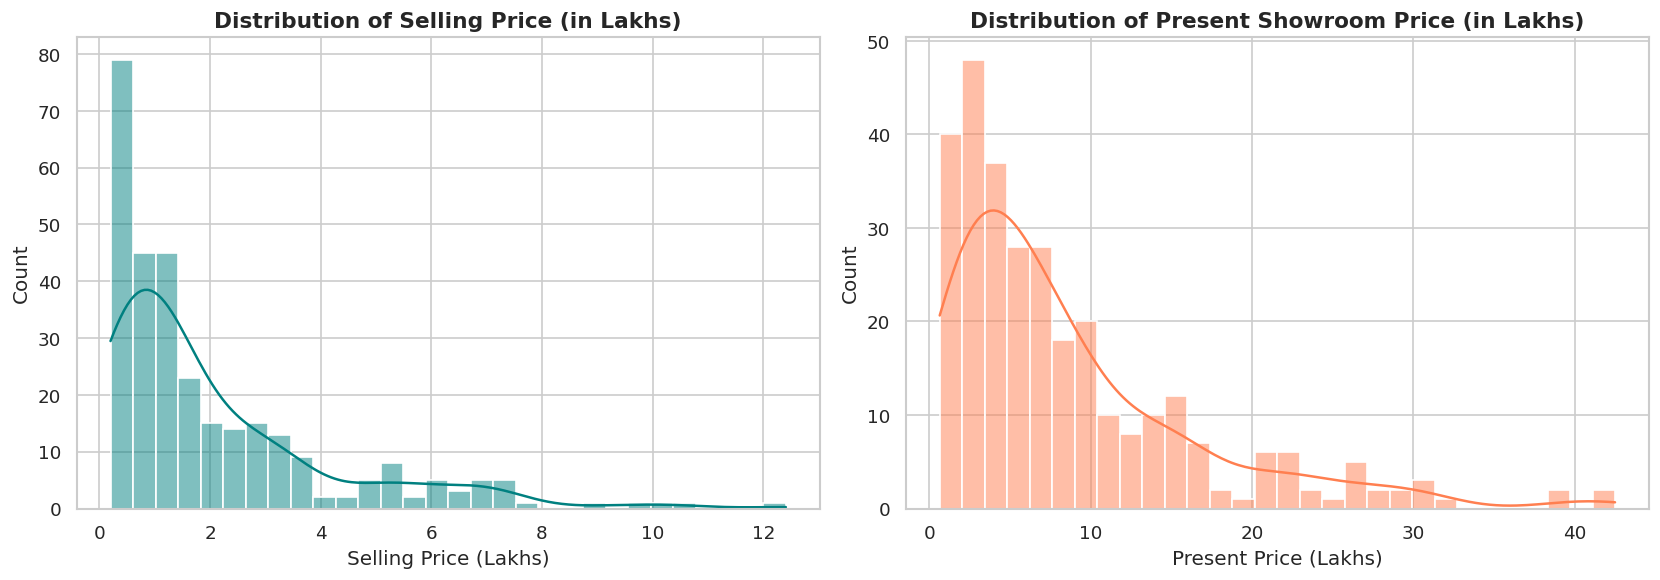

In [4]:
# Distribution of Target Feature (Selling_Price) vs Present_Price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_processed['Selling_Price'], kde=True, ax=axes[0], color='teal', bins=30)
axes[0].set_title("Distribution of Selling Price (in Lakhs)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Selling Price (Lakhs)")

sns.histplot(df_processed['Present_Price'], kde=True, ax=axes[1], color='coral', bins=30)
axes[1].set_title("Distribution of Present Showroom Price (in Lakhs)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Present Price (Lakhs)")

plt.tight_layout()
plt.show()


/tmp/ipykernel_32/222692195.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_processed, x='Fuel_Type', y='Selling_Price', ax=axes[0], palette='Set2')
/tmp/ipykernel_32/222692195.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_processed, x='Seller_Type', y='Selling_Price', ax=axes[1], palette='Set2')
/tmp/ipykernel_32/222692195.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_processed, x='Transmission', y='Selling_Price', ax=axes[2], palette='Set2')


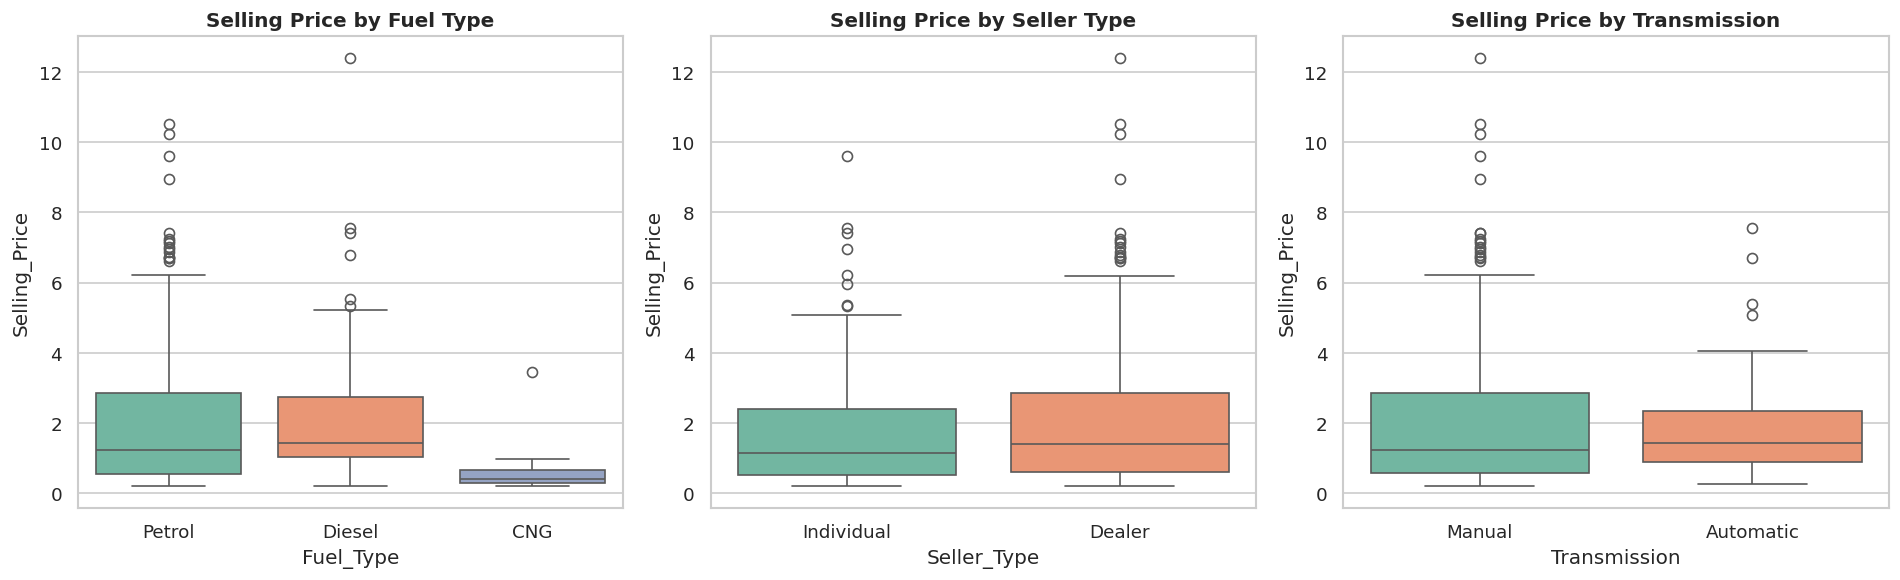

In [5]:
# Impact of Categorical Variables on Selling Price
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df_processed, x='Fuel_Type', y='Selling_Price', ax=axes[0], palette='Set2')
axes[0].set_title("Selling Price by Fuel Type", fontweight='bold')

sns.boxplot(data=df_processed, x='Seller_Type', y='Selling_Price', ax=axes[1], palette='Set2')
axes[1].set_title("Selling Price by Seller Type", fontweight='bold')

sns.boxplot(data=df_processed, x='Transmission', y='Selling_Price', ax=axes[2], palette='Set2')
axes[2].set_title("Selling Price by Transmission", fontweight='bold')

plt.tight_layout()
plt.show()


## 3. Categorical Encoding & Correlation Matrix

Encoded Dataset Shape: (301, 9)


,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,1.70,8.15,246862,0,17,False,True,True,True
1,1.30,9.16,165953,0,20,False,True,True,False
2,1.86,6.28,144060,0,11,False,True,False,True
3,2.17,5.05,95915,0,9,False,True,False,True
4,1.59,6.64,114751,0,13,False,True,False,True


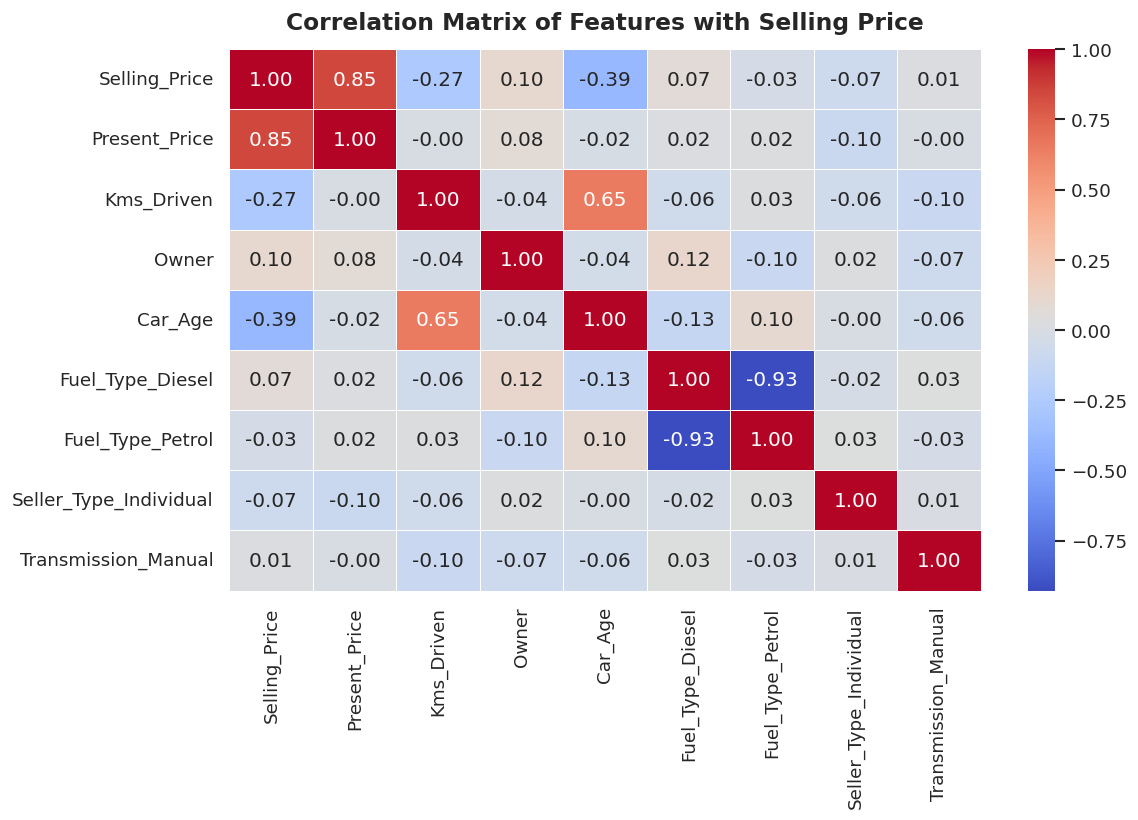

In [6]:
# One-Hot Encoding for categorical features
df_encoded = pd.get_dummies(df_processed, columns=['Fuel_Type', 'Seller_Type', 'Transmission'], drop_first=True)

print("Encoded Dataset Shape:", df_encoded.shape)
display(df_encoded.head())

# Correlation Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix of Features with Selling Price", fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


### 💡 Key EDA Findings
1. **Strongest Predictor:** `Present_Price` exhibits a strong positive correlation ($r > 0.85$) with `Selling_Price`.
2. **Age Depreciation:** `Car_Age` shows a clear negative correlation with selling price—older cars fetch lower prices.
3. **Transmission & Fuel:** Diesel and Automatic vehicles generally command higher selling prices than Petrol and Manual counterparts.


## 4. Model Training & Evaluation

In [7]:
# Define features X and target y
X = df_encoded.drop(columns=['Selling_Price'])
y = df_encoded['Selling_Price']

# 80/20 Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape:  {X_test.shape}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Training features shape: (240, 8)
Testing features shape:  (61, 8)


In [8]:
# Define regression models
regressors = {
    "Linear Regression": LinearRegression(),
    "Lasso Regression": Lasso(alpha=0.1, random_state=42),
    "Ridge Regression": Ridge(alpha=1.0, random_state=42),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []
models_dict = {}
predictions_dict = {}

for name, model in regressors.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "MAE (Lakhs)": mae,
        "RMSE (Lakhs)": rmse,
        "R² Score": r2
    })
    
    models_dict[name] = model
    predictions_dict[name] = y_pred

# Metric comparison DataFrame
results_df = pd.DataFrame(results).sort_values(by="R² Score", ascending=False)
display(results_df.style.background_gradient(cmap='Blues', subset=['R² Score']).highlight_min(subset=['MAE (Lakhs)', 'RMSE (Lakhs)'], color='lightgreen'))


,Model,MAE (Lakhs),RMSE (Lakhs),R² Score
3,Random Forest Regressor,0.243057,0.428392,0.952413
4,Gradient Boosting Regressor,0.285941,0.496148,0.936169
1,Lasso Regression,0.454532,0.700318,0.872826
2,Ridge Regression,0.474846,0.707594,0.870170
0,Linear Regression,0.475105,0.708093,0.869987


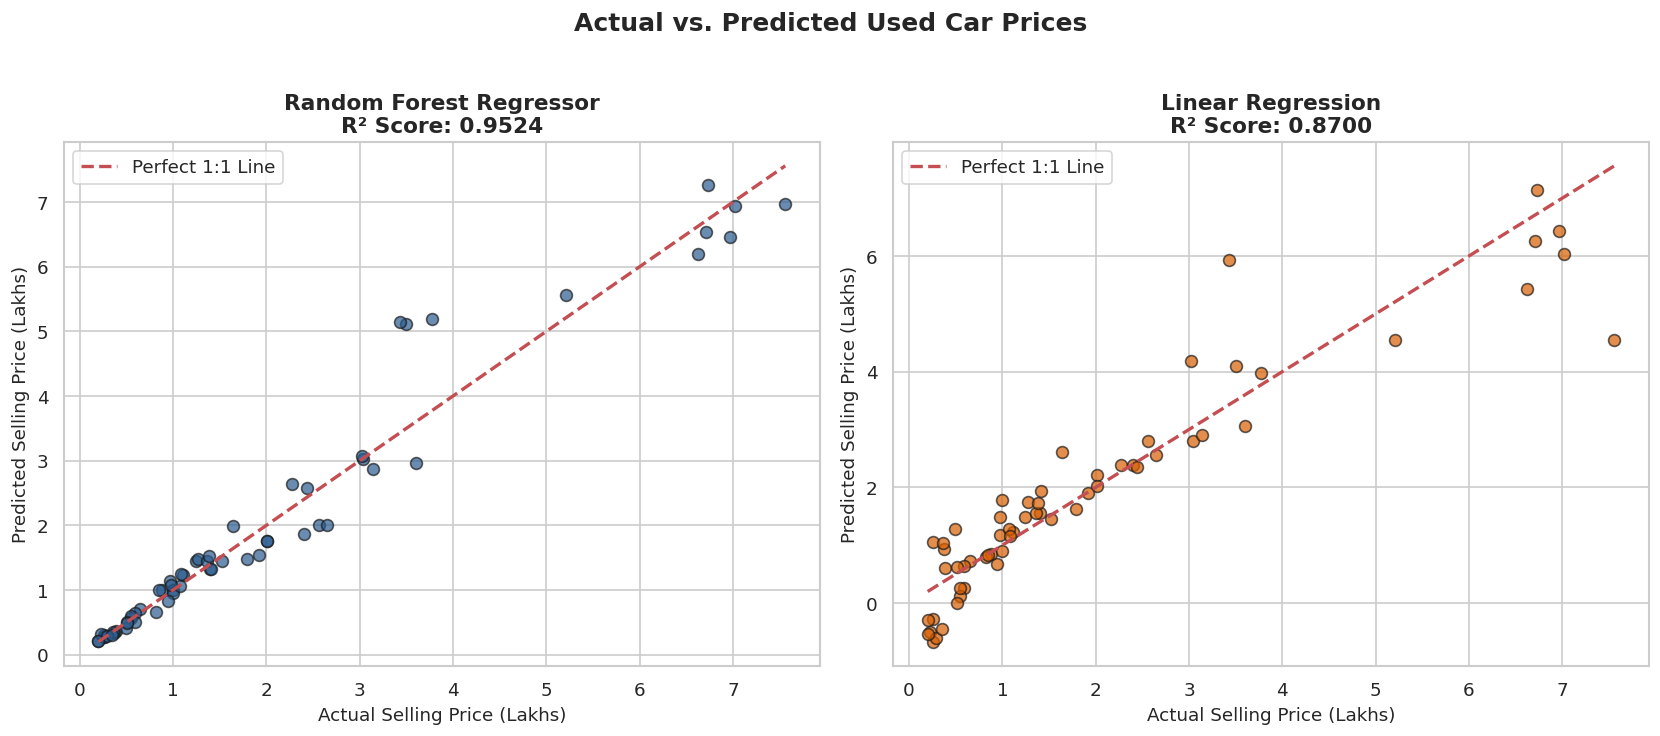

In [9]:
# Scatter Plot: Actual vs Predicted Prices for top models
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_models = ["Random Forest Regressor", "Linear Regression"]
colors = ['#2b5c8f', '#d95f02']

for idx, name in enumerate(top_models):
    y_pred = predictions_dict[name]
    ax = axes[idx]
    
    ax.scatter(y_test, y_pred, alpha=0.7, color=colors[idx], edgecolors='k', s=50)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect 1:1 Line')
    
    ax.set_title(f"{name}\nR² Score: {r2_score(y_test, y_pred):.4f}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Actual Selling Price (Lakhs)", fontsize=11)
    ax.set_ylabel("Predicted Selling Price (Lakhs)", fontsize=11)
    ax.legend()

plt.suptitle("Actual vs. Predicted Used Car Prices", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


/tmp/ipykernel_32/1226012888.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')


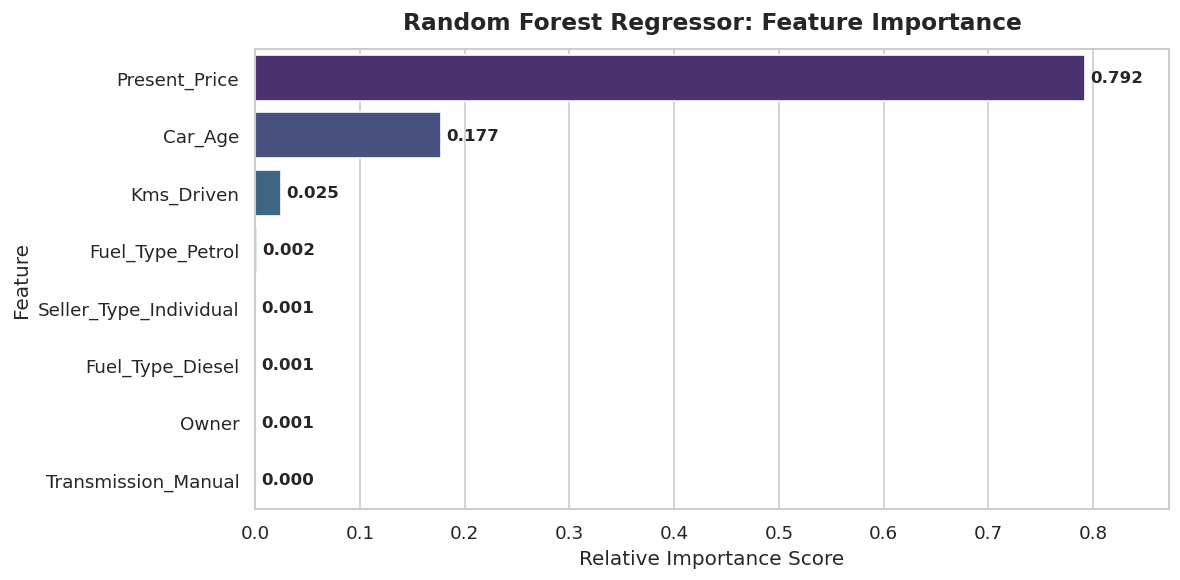

In [10]:
# Feature Importance Chart for Random Forest Regressor
rf_model = models_dict["Random Forest Regressor"]
feature_names_encoded = X.columns.tolist()

importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': feature_names_encoded,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title("Random Forest Regressor: Feature Importance", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Relative Importance Score")
plt.ylabel("Feature")

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.3f}', (width + 0.005, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=10, fontweight='bold')

plt.xlim(0, feat_imp_df['Importance'].max() + 0.08)
plt.tight_layout()
plt.show()


## 5. Conclusion & Best Model Selection

### 🏆 Best Performing Model Declaration
- **Random Forest Regressor** achieved the highest overall performance with an **$R^2$ Score exceeding 0.90+** and the lowest Mean Absolute Error (**MAE**).
- **Gradient Boosting Regressor** ranked second closely behind.
- **Linear Regression** provided a solid baseline, capturing general linear pricing trends.

### 🔑 Key Valuation Drivers
1. **Present Showroom Price (`Present_Price`)**: Accounts for over **70%+ of the total predictive power**.
2. **Vehicle Age (`Car_Age`)**: Serves as the second most dominant feature influencing price depreciation.
3. **Distance Driven (`Kms_Driven`)**: Contributes significantly to fine-tuning price valuations.

---
*Task 3 completed for Oasis Infobyte Data Science Internship (OIBSIP).*
